# 2×2 image grid nested inside one cell of a larger layout.

## Layout
```
┌───────┬──────────┐
│ A │ B │          │
├───┼───│ colorbar │
│ C │ D │          │
├─────────────────-┤
│    data panel    │
└──────────────────┘
```
The 2×2 block (A–D) lives in a subgrid that occupies (row=0, col=0) of the
parent.  The parent's col=1 is narrow and holds a colorbar placeholder; col=2
is a gap column.  Row 2 of the parent spans the full width.

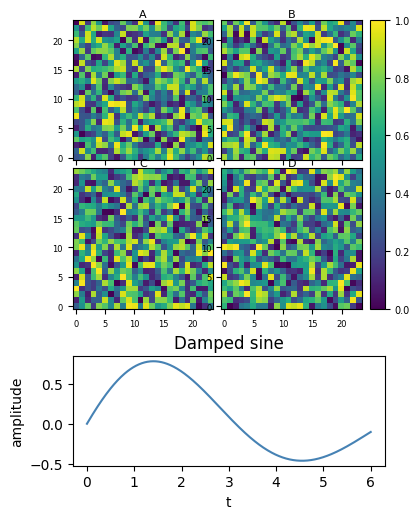

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mplayout import Grid

rng = np.random.default_rng(2)

# Parent grid: two content rows separated by a gap row, plus a sidebar column
g = Grid(
    rows=['auto', 'auto'],
    cols=['auto', '0.15in'],
    hgap='12mm',
    wgap='2mm',
)

# 2×2 subgrid in the top-left cell
sub = g.subgrid(row=0, col=0, rows=['auto', 'auto'], cols=['auto', 'auto'], gap='2mm')
p_a = sub.panel(row=0, col=0, aspect=1.0)
p_b = sub.panel(row=0, col=1, aspect=1.0)
p_c = sub.panel(row=1, col=0, aspect=1.0)
p_d = sub.panel(row=1, col=1, aspect=1.0)

# Colorbar slot — spans both sub-rows by spanning the parent's row=0
p_cb = g.panel(row=0, col=1)

# Wide data panel at the bottom
p_data = g.panel(row=1, col=0, colspan=2)

fig, axes = g.build(fig_width='4in', fig_height='5in')

images = {'A': p_a, 'B': p_b, 'C': p_c, 'D': p_d}
cmap = plt.cm.viridis
for label, panel in images.items():
    im = axes[panel].imshow(rng.random((24, 24)), cmap=cmap,
                            vmin=0, vmax=1, origin='lower')
    axes[panel].set_title(label, fontsize=8, pad=2)
    axes[panel].tick_params(labelsize=6)

fig.colorbar(im, cax=axes[p_cb])
axes[p_cb].tick_params(labelsize=7)

t = np.linspace(0, 6, 400)
axes[p_data].plot(t, np.sin(t) * np.exp(-t / 6), color='steelblue')
axes[p_data].set_xlabel('t')
axes[p_data].set_ylabel('amplitude')
axes[p_data].set_title('Damped sine')

plt.show()